In [1]:
# ============================================
# COMMON PREPROCESSING - LOAD DATASETS
# ============================================

import os
import pandas as pd
import numpy as np

processed_folder = r"C:\MachineHealthProject\processed"

# File paths
mimii_path = os.path.join(processed_folder, "MIMII_processed.csv")
cwru_path = os.path.join(processed_folder, "CWRU_processed.csv")
ib_path = os.path.join(processed_folder, "IB_processed.csv")

# Load datasets
mimii_df = pd.read_csv(mimii_path)
cwru_df = pd.read_csv(cwru_path)
ib_df = pd.read_csv(ib_path)

print("=== DATASETS LOADED SUCCESSFULLY ===")

print("\nMIMII:")
print("Shape:", mimii_df.shape)

print("\nCWRU:")
print("Shape:", cwru_df.shape)

print("\nIB:")
print("Shape:", ib_df.shape)

=== DATASETS LOADED SUCCESSFULLY ===

MIMII:
Shape: (4, 8)

CWRU:
Shape: (4, 15)

IB:
Shape: (178, 12)


In [2]:
# ============================================
# STEP 2 - COMPARE FEATURES
# ============================================

print("=== MIMII COLUMNS ===")
print(list(mimii_df.columns))

print("\n=== CWRU COLUMNS ===")
print(list(cwru_df.columns))

print("\n=== IB COLUMNS ===")
print(list(ib_df.columns))

=== MIMII COLUMNS ===
['File', 'Label', 'Mean', 'Std', 'Min', 'Max', 'RMS', 'Duration']

=== CWRU COLUMNS ===
['File', 'Label', 'RPM', 'Sampling_Rate', 'Samples', 'Duration', 'Mean', 'Median', 'Std', 'Min', 'Max', 'RMS', 'Peak_to_Peak', 'Variance', 'Crest_Factor']

=== IB COLUMNS ===
['Sample', 'Label', 'Samples', 'Mean', 'Median', 'Std', 'Min', 'Max', 'RMS', 'Peak_to_Peak', 'Variance', 'Crest_Factor']


In [3]:
# ============================================
# STEP 3 - FIND COMMON FEATURES
# ============================================

mimii_features = set(mimii_df.columns)
cwru_features = set(cwru_df.columns)
ib_features = set(ib_df.columns)

# Common columns in all three datasets
common_features = sorted(
    mimii_features.intersection(cwru_features).intersection(ib_features)
)

print("=== COMMON FEATURES IN ALL THREE DATASETS ===")

for feature in common_features:
    print(feature)

print("\nTotal common features:", len(common_features))

=== COMMON FEATURES IN ALL THREE DATASETS ===
Label
Max
Mean
Min
RMS
Std

Total common features: 6


In [4]:
# ============================================
# STEP 4 - COMPARE LABELS
# ============================================

print("=== MIMII LABELS ===")
print(mimii_df["Label"].value_counts())
print("Unique labels:", mimii_df["Label"].unique())

print("\n=== CWRU LABELS ===")
print(cwru_df["Label"].value_counts())
print("Unique labels:", cwru_df["Label"].unique())

print("\n=== IB LABELS ===")
print(ib_df["Label"].value_counts())
print("Unique labels:", ib_df["Label"].unique())

=== MIMII LABELS ===
Label
Normal      2
Abnormal    2
Name: count, dtype: int64
Unique labels: ['Normal' 'Abnormal']

=== CWRU LABELS ===
Label
Normal              1
Inner Race Fault    1
Ball Fault          1
Outer Race Fault    1
Name: count, dtype: int64
Unique labels: ['Normal' 'Inner Race Fault' 'Ball Fault' 'Outer Race Fault']

=== IB LABELS ===
Label
1    20
2    20
4    20
5    20
7    20
8    20
9    20
3    19
6    19
Name: count, dtype: int64
Unique labels: [1 2 3 4 5 6 7 8 9]


In [5]:
# ============================================
# STEP 5 - INSPECT IB LABELS
# ============================================

print("=== IB LABEL INFORMATION ===")

print("\nUnique IB labels:")
print(sorted(ib_df["Label"].unique()))

print("\nNumber of samples per IB label:")
print(ib_df["Label"].value_counts().sort_index())

print("\nSample rows for each IB label:")

for label in sorted(ib_df["Label"].unique()):
    
    print("\n------------------------------")
    print("IB Label:", label)
    
    display(
        ib_df[ib_df["Label"] == label].head(3)
    )

=== IB LABEL INFORMATION ===

Unique IB labels:
[1, 2, 3, 4, 5, 6, 7, 8, 9]

Number of samples per IB label:
Label
1    20
2    20
3    19
4    20
5    20
6    19
7    20
8    20
9    20
Name: count, dtype: int64

Sample rows for each IB label:

------------------------------
IB Label: 1


,Sample,Label,Samples,Mean,Median,Std,Min,Max,RMS,Peak_to_Peak,Variance,Crest_Factor
0,1,1,3571,0.009641,0.0098,0.017640,-0.0845,0.0711,0.020103,0.1556,0.000311,4.203444
1,2,1,3571,0.010269,0.0108,0.059201,-3.3340,0.1002,0.060085,3.4342,0.003505,55.488031
2,3,1,3571,0.008430,0.0088,0.018029,-0.0874,0.0750,0.019902,0.1624,0.000325,4.391489



------------------------------
IB Label: 2


,Sample,Label,Samples,Mean,Median,Std,Min,Max,RMS,Peak_to_Peak,Variance,Crest_Factor
20,21,2,3571,0.017695,0.0176,0.065330,-0.9265,0.6749,0.067684,1.6014,0.004268,13.688642
21,22,2,3571,0.017796,0.0176,0.051157,-0.3694,0.4211,0.054164,0.7905,0.002617,7.774560
22,23,2,3571,0.018681,0.0186,0.061913,-0.5104,0.6263,0.064670,1.1367,0.003833,9.684568



------------------------------
IB Label: 3


...

,Sample,Label,Samples,Mean,Median,Std,Min,Max,RMS,Peak_to_Peak,Variance,Crest_Factor
118,119,7,3571,0.021885,0.0225,0.024120,-0.1146,0.1207,0.032568,0.2353,0.000582,3.706066
119,120,7,3571,0.021188,0.0205,0.024187,-0.1924,0.1177,0.032154,0.3101,0.000585,5.983614
120,121,7,3571,0.021067,0.0205,0.029279,-0.1594,0.1353,0.036070,0.2947,0.000857,4.419162



------------------------------
IB Label: 8


,Sample,Label,Samples,Mean,Median,Std,Min,Max,RMS,Peak_to_Peak,Variance,Crest_Factor
138,139,8,3571,-0.046616,0.0138,0.272302,-1.7908,0.8636,0.276264,2.6544,0.074149,6.482211
139,140,8,3571,-0.095954,-0.0115,0.315223,-2.1630,0.7555,0.329504,2.9185,0.099366,6.564415
140,141,8,3571,-0.095748,-0.0142,0.334323,-1.8791,1.0919,0.347763,2.9710,0.111772,5.403385



------------------------------
IB Label: 9


,Sample,Label,Samples,Mean,Median,Std,Min,Max,RMS,Peak_to_Peak,Variance,Crest_Factor
158,159,9,3571,-0.020404,-0.0155,0.061524,-3.2873,0.0536,0.064819,3.3409,0.003785,50.715271
159,160,9,3571,0.017860,0.0215,0.060992,-3.2232,0.1002,0.063554,3.3234,0.003720,50.716259
160,161,9,3571,0.016579,0.0186,0.060878,-3.2163,0.1343,0.063095,3.3506,0.003706,50.975158


In [6]:
# ============================================
# STEP 6 - ADD DATASET IDENTIFIER
# ============================================

# Create copies so original dataframes are not changed
mimii_common = mimii_df.copy()
cwru_common = cwru_df.copy()
ib_common = ib_df.copy()

# Add dataset/source information
mimii_common["Dataset"] = "MIMII"
cwru_common["Dataset"] = "CWRU"
ib_common["Dataset"] = "IB"

# Convert IB numeric labels into clearly identified class names
ib_common["Original_Label"] = ib_common["Label"]
ib_common["Label"] = "IB_Class_" + ib_common["Label"].astype(str)

print("=== DATASET IDENTIFIERS ADDED ===")

print("\nMIMII:")
print(mimii_common["Dataset"].value_counts())

print("\nCWRU:")
print(cwru_common["Dataset"].value_counts())

print("\nIB:")
print(ib_common["Dataset"].value_counts())

print("\nIB labels after conversion:")
print(sorted(ib_common["Label"].unique()))

=== DATASET IDENTIFIERS ADDED ===

MIMII:
Dataset
MIMII    4
Name: count, dtype: int64

CWRU:
Dataset
CWRU    4
Name: count, dtype: int64

IB:
Dataset
IB    178
Name: count, dtype: int64

IB labels after conversion:
['IB_Class_1', 'IB_Class_2', 'IB_Class_3', 'IB_Class_4', 'IB_Class_5', 'IB_Class_6', 'IB_Class_7', 'IB_Class_8', 'IB_Class_9']


In [7]:
# ============================================
# STEP 7 - CREATE COMMON FEATURE DATASETS
# ============================================

common_features = [
    "Mean",
    "Std",
    "Min",
    "Max",
    "RMS"
]

# Keep common features + label + dataset
mimii_common_final = mimii_common[
    ["Dataset", "Label"] + common_features
].copy()

cwru_common_final = cwru_common[
    ["Dataset", "Label"] + common_features
].copy()

ib_common_final = ib_common[
    ["Dataset", "Label"] + common_features
].copy()

print("=== COMMON FEATURE DATASETS ===")

print("\nMIMII shape:", mimii_common_final.shape)
print("CWRU shape:", cwru_common_final.shape)
print("IB shape:", ib_common_final.shape)

print("\nCommon features:")
print(common_features)

print("\nMIMII:")
display(mimii_common_final)

print("\nCWRU:")
display(cwru_common_final.head())

print("\nIB:")
display(ib_common_final.head())

=== COMMON FEATURE DATASETS ===

MIMII shape: (4, 7)
CWRU shape: (4, 7)
IB shape: (178, 7)

Common features:
['Mean', 'Std', 'Min', 'Max', 'RMS']

MIMII:


,Dataset,Label,Mean,Std,Min,Max,RMS
0,MIMII,Normal,0.000002,0.009185,-0.075134,0.074951,0.009185
1,MIMII,Normal,0.000002,0.009185,-0.075134,0.074951,0.009185
2,MIMII,Abnormal,0.000008,0.012520,-0.048981,0.053375,0.012520
3,MIMII,Abnormal,0.000008,0.012520,-0.048981,0.053375,0.012520



CWRU:


,Dataset,Label,Mean,Std,Min,Max,RMS
0,CWRU,Normal,0.012558,0.072687,-0.286638,0.311254,0.073764
1,CWRU,Inner Race Fault,0.013444,0.291216,-1.379886,1.739030,0.291526
2,CWRU,Ball Fault,0.012607,0.138662,-0.607020,0.603934,0.139234
3,CWRU,Outer Race Fault,0.023171,0.669104,-3.408701,3.630425,0.669506



IB:


,Dataset,Label,Mean,Std,Min,Max,RMS
0,IB,IB_Class_1,0.009641,0.017640,-0.0845,0.0711,0.020103
1,IB,IB_Class_1,0.010269,0.059201,-3.3340,0.1002,0.060085
2,IB,IB_Class_1,0.008430,0.018029,-0.0874,0.0750,0.019902
3,IB,IB_Class_1,0.044781,0.018601,-0.0495,0.1226,0.048490
4,IB,IB_Class_1,0.012959,0.018746,-0.0709,0.0720,0.022789


In [8]:
# ============================================
# STEP 8 - FINAL QUALITY CHECK
# ============================================

datasets = {
    "MIMII": mimii_common_final,
    "CWRU": cwru_common_final,
    "IB": ib_common_final
}

for name, df in datasets.items():

    print("\n========================================")
    print(name)
    print("========================================")

    print("\nShape:", df.shape)

    print("\nMissing values:")
    print(df.isnull().sum())

    print("\nDuplicate rows:")
    print(df.duplicated().sum())

    # Check infinite values only in numerical features
    numeric_data = df[common_features]

    print("\nInfinite values:")
    print(np.isinf(numeric_data.to_numpy()).sum())

print("\n=== COMMON DATA QUALITY CHECK COMPLETE ===")


MIMII

Shape: (4, 7)

Missing values:
Dataset    0
Label      0
Mean       0
Std        0
Min        0
Max        0
RMS        0
dtype: int64

Duplicate rows:
2

Infinite values:
0

CWRU

Shape: (4, 7)

Missing values:
Dataset    0
Label      0
Mean       0
Std        0
Min        0
Max        0
RMS        0
dtype: int64

Duplicate rows:
0

Infinite values:
0

IB

Shape: (178, 7)

Missing values:
Dataset    0
Label      0
Mean       0
Std        0
Min        0
Max        0
RMS        0
dtype: int64

Duplicate rows:
0

Infinite values:
0

=== COMMON DATA QUALITY CHECK COMPLETE ===


In [9]:
# ============================================
# STEP 9 - COMBINE COMMON FEATURES
# ============================================

# Combine the three common-feature datasets
combined_df = pd.concat(
    [
        mimii_common_final,
        cwru_common_final,
        ib_common_final
    ],
    ignore_index=True
)

print("=== COMBINED DATASET ===")

print("Shape:", combined_df.shape)

print("\nColumns:")
print(list(combined_df.columns))

print("\nSamples by dataset:")
print(combined_df["Dataset"].value_counts())

print("\nLabels by dataset:")
print(
    combined_df.groupby("Dataset")["Label"]
    .value_counts()
)

print("\nFirst 10 rows:")
display(combined_df.head(10))

=== COMBINED DATASET ===
Shape: (186, 7)

Columns:
['Dataset', 'Label', 'Mean', 'Std', 'Min', 'Max', 'RMS']

Samples by dataset:
Dataset
IB       178
MIMII      4
CWRU       4
Name: count, dtype: int64

Labels by dataset:
Dataset  Label           
CWRU     Ball Fault           1
         Inner Race Fault     1
         Normal               1
         Outer Race Fault     1
IB       IB_Class_1          20
         IB_Class_2          20
         IB_Class_4          20
         IB_Class_5          20
         IB_Class_7          20
         IB_Class_8          20
         IB_Class_9          20
         IB_Class_3          19
         IB_Class_6          19
MIMII    Abnormal             2
         Normal               2
Name: count, dtype: int64

First 10 rows:


,Dataset,Label,Mean,Std,Min,Max,RMS
0,MIMII,Normal,0.000002,0.009185,-0.075134,0.074951,0.009185
1,MIMII,Normal,0.000002,0.009185,-0.075134,0.074951,0.009185
2,MIMII,Abnormal,0.000008,0.012520,-0.048981,0.053375,0.012520
3,MIMII,Abnormal,0.000008,0.012520,-0.048981,0.053375,0.012520
4,CWRU,Normal,0.012558,0.072687,-0.286638,0.311254,0.073764
5,CWRU,Inner Race Fault,0.013444,0.291216,-1.379886,1.739030,0.291526
6,CWRU,Ball Fault,0.012607,0.138662,-0.607020,0.603934,0.139234
7,CWRU,Outer Race Fault,0.023171,0.669104,-3.408701,3.630425,0.669506
8,IB,IB_Class_1,0.009641,0.017640,-0.084500,0.071100,0.020103
9,IB,IB_Class_1,0.010269,0.059201,-3.334000,0.100200,0.060085


In [10]:
# ============================================
# STEP 10 - FEATURE RANGE COMPARISON
# ============================================

print("=== FEATURE RANGE COMPARISON ===")

for feature in common_features:

    print("\n----------------------------------------")
    print("Feature:", feature)

    range_table = combined_df.groupby("Dataset")[feature].agg(
        ["min", "max", "mean", "std"]
    )

    display(range_table)

print("\n=== OVERALL FEATURE STATISTICS ===")
display(combined_df[common_features].describe().T)

=== FEATURE RANGE COMPARISON ===

----------------------------------------
Feature: Mean


,min,max,mean,std
Dataset,,,,
CWRU,0.012558,0.023171,0.015445,0.005167
IB,-0.139044,0.044781,-0.003071,0.038634
MIMII,0.000002,0.000008,0.000005,0.000003



----------------------------------------
Feature: Std


,min,max,mean,std
Dataset,,,,
CWRU,0.072687,0.669104,0.292917,0.266968
IB,0.017640,0.374675,0.118147,0.096222
MIMII,0.009185,0.012520,0.010853,0.001926



----------------------------------------
Feature: Min


...

,min,max,mean,std
Dataset,,,,
CWRU,0.311254,3.630425,1.571161,1.504620
IB,0.041900,1.399200,0.545154,0.372228
MIMII,0.053375,0.074951,0.064163,0.012457



----------------------------------------
Feature: RMS


,min,max,mean,std
Dataset,,,,
CWRU,0.073764,0.669506,0.293507,0.266750
IB,0.018764,0.399643,0.123001,0.097895
MIMII,0.009185,0.012520,0.010853,0.001926



=== OVERALL FEATURE STATISTICS ===


,count,mean,std,min,25%,50%,75%,max
Mean,186.0,-0.002607,0.037893,-0.139044,-0.010920,0.017196,0.021299,0.044781
Std,186.0,0.119598,0.104505,0.009185,0.028665,0.092422,0.174609,0.669104
Min,186.0,-1.065686,0.911186,-3.408701,-1.548850,-0.934750,-0.157150,-0.048981
Max,186.0,0.556875,0.443735,0.041900,0.129375,0.576800,0.794200,3.630425
RMS,186.0,0.124256,0.105934,0.009185,0.033979,0.095251,0.174861,0.669506


In [11]:
# ============================================
# STEP 11 - FEATURE STANDARDIZATION
# ============================================

from sklearn.preprocessing import StandardScaler

# Features to scale
common_features = [
    "Mean",
    "Std",
    "Min",
    "Max",
    "RMS"
]

# Create scaler
scaler = StandardScaler()

# Fit and transform the common features
scaled_values = scaler.fit_transform(
    combined_df[common_features]
)

# Create a new dataframe
scaled_df = combined_df.copy()

# Replace feature values with standardized values
scaled_df[common_features] = scaled_values

print("=== STANDARDIZATION COMPLETE ===")

print("\nOriginal dataset shape:")
print(combined_df.shape)

print("\nScaled dataset shape:")
print(scaled_df.shape)

print("\nScaled feature statistics:")
display(
    scaled_df[common_features].describe().T
)

print("\nFirst 10 scaled rows:")
display(scaled_df.head(10))

=== STANDARDIZATION COMPLETE ===

Original dataset shape:
(186, 7)

Scaled dataset shape:
(186, 7)

Scaled feature statistics:


,count,mean,std,min,25%,50%,75%,max
Mean,186.0,0.000000e+00,1.002699,-3.610343,-0.219986,0.524011,0.632593,1.253958
Std,186.0,-9.550306e-17,1.002699,-1.059391,-0.872483,-0.260752,0.527816,5.272384
Min,186.0,-1.050534e-16,1.002699,-2.578329,-0.531689,0.144087,0.999783,1.118816
Max,186.0,-2.578583e-16,1.002699,-1.163678,-0.966013,0.045024,0.536278,6.945234
RMS,186.0,3.820122e-17,1.002699,-1.089187,-0.854501,-0.274541,0.478996,5.160969



First 10 scaled rows:


,Dataset,Label,Mean,Std,Min,Max,RMS
0,MIMII,Normal,0.069049,-1.059391,1.090036,-1.088993,-1.089187
1,MIMII,Normal,0.069049,-1.059391,1.090036,-1.088993,-1.089187
2,MIMII,Abnormal,0.069207,-1.027388,1.118816,-1.137748,-1.057616
3,MIMII,Abnormal,0.069207,-1.027388,1.118816,-1.137748,-1.057616
4,CWRU,Normal,0.401295,-0.450103,0.857291,-0.555025,-0.477925
5,CWRU,Inner Race Fault,0.424723,1.646631,-0.345756,2.671291,1.583266
6,CWRU,Ball Fault,0.402587,0.182908,0.504731,0.106337,0.141767
7,CWRU,Outer Race Fault,0.682140,5.272384,-2.578329,6.945234,5.160969
8,IB,IB_Class_1,0.324091,-0.978266,1.079729,-1.097696,-0.985848
9,IB,IB_Class_1,0.340723,-0.579499,-2.496126,-1.031939,-0.607401


In [12]:
# ============================================
# STEP 12 - SAVE COMBINED PREPROCESSED DATA
# ============================================

import os

processed_folder = r"C:\MachineHealthProject\processed"

# Create folder if it does not exist
os.makedirs(processed_folder, exist_ok=True)

# File path
combined_output_path = os.path.join(
    processed_folder,
    "Combined_Common_Features.csv"
)

# Save standardized dataset
scaled_df.to_csv(
    combined_output_path,
    index=False
)

print("=== COMBINED DATASET SAVED ===")
print("File:", combined_output_path)

# Verify saved file
combined_check = pd.read_csv(combined_output_path)

print("\n=== SAVED FILE VERIFICATION ===")
print("Shape:", combined_check.shape)

print("\nColumns:")
print(list(combined_check.columns))

print("\nDataset counts:")
print(combined_check["Dataset"].value_counts())

print("\nFirst 5 rows:")
display(combined_check.head())

=== COMBINED DATASET SAVED ===
File: C:\MachineHealthProject\processed\Combined_Common_Features.csv

=== SAVED FILE VERIFICATION ===
Shape: (186, 7)

Columns:
['Dataset', 'Label', 'Mean', 'Std', 'Min', 'Max', 'RMS']

Dataset counts:
Dataset
IB       178
MIMII      4
CWRU       4
Name: count, dtype: int64

First 5 rows:


,Dataset,Label,Mean,Std,Min,Max,RMS
0,MIMII,Normal,0.069049,-1.059391,1.090036,-1.088993,-1.089187
1,MIMII,Normal,0.069049,-1.059391,1.090036,-1.088993,-1.089187
2,MIMII,Abnormal,0.069207,-1.027388,1.118816,-1.137748,-1.057616
3,MIMII,Abnormal,0.069207,-1.027388,1.118816,-1.137748,-1.057616
4,CWRU,Normal,0.401295,-0.450103,0.857291,-0.555025,-0.477925


In [14]:
# ============================================
# STEP 13 - CHECK SPLIT FEASIBILITY
# ============================================

print("=== SPLIT FEASIBILITY CHECK ===")

for dataset_name in scaled_df["Dataset"].unique():

    dataset_part = scaled_df[
        scaled_df["Dataset"] == dataset_name
    ]

    print("\n----------------------------------------")
    print("Dataset:", dataset_name)
    print("Total samples:", len(dataset_part))

    print("\nLabel distribution:")
    print(dataset_part["Label"].value_counts())

    print("\nMinimum samples in a class:",
          dataset_part["Label"].value_counts().min())

=== SPLIT FEASIBILITY CHECK ===

----------------------------------------
Dataset: MIMII
Total samples: 4

Label distribution:
Label
Normal      2
Abnormal    2
Name: count, dtype: int64

Minimum samples in a class: 2

----------------------------------------
Dataset: CWRU
Total samples: 4

Label distribution:
Label
Normal              1
Inner Race Fault    1
Ball Fault          1
Outer Race Fault    1
Name: count, dtype: int64

Minimum samples in a class: 1

----------------------------------------
Dataset: IB
Total samples: 178

Label distribution:
Label
IB_Class_1    20
IB_Class_2    20
IB_Class_4    20
IB_Class_5    20
IB_Class_7    20
IB_Class_8    20
IB_Class_9    20
IB_Class_3    19
IB_Class_6    19
Name: count, dtype: int64

Minimum samples in a class: 19


In [15]:
# ============================================
# STEP 14 - IB TRAIN / VALIDATION / TEST SPLIT
# ============================================

from sklearn.model_selection import train_test_split

# Select IB data only
ib_model_df = scaled_df[
    scaled_df["Dataset"] == "IB"
].copy()

# Features
X_ib = ib_model_df[common_features].copy()

# Target
y_ib = ib_model_df["Label"].copy()

print("=== IB MODEL DATA ===")
print("Total samples:", len(ib_model_df))
print("Features:", common_features)

print("\nClass distribution:")
print(y_ib.value_counts().sort_index())

# 80% training, 20% temporary
X_ib_train, X_ib_temp, y_ib_train, y_ib_temp = train_test_split(
    X_ib,
    y_ib,
    test_size=0.20,
    random_state=42,
    stratify=y_ib
)

# 10% validation, 10% test
X_ib_val, X_ib_test, y_ib_val, y_ib_test = train_test_split(
    X_ib_temp,
    y_ib_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_ib_temp
)

print("\n=== IB SPLIT RESULTS ===")
print("Training samples:", len(X_ib_train))
print("Validation samples:", len(X_ib_val))
print("Testing samples:", len(X_ib_test))

print("\nTraining class distribution:")
print(y_ib_train.value_counts().sort_index())

print("\nValidation class distribution:")
print(y_ib_val.value_counts().sort_index())

print("\nTesting class distribution:")
print(y_ib_test.value_counts().sort_index())

=== IB MODEL DATA ===
Total samples: 178
Features: ['Mean', 'Std', 'Min', 'Max', 'RMS']

Class distribution:
Label
IB_Class_1    20
IB_Class_2    20
IB_Class_3    19
IB_Class_4    20
IB_Class_5    20
IB_Class_6    19
IB_Class_7    20
IB_Class_8    20
IB_Class_9    20
Name: count, dtype: int64

=== IB SPLIT RESULTS ===
Training samples: 142
Validation samples: 18
Testing samples: 18

Training class distribution:
Label
IB_Class_1    16
IB_Class_2    16
IB_Class_3    15
IB_Class_4    16
IB_Class_5    16
IB_Class_6    15
IB_Class_7    16
IB_Class_8    16
IB_Class_9    16
Name: count, dtype: int64

Validation class distribution:
Label
IB_Class_1    2
IB_Class_2    2
IB_Class_3    2
IB_Class_4    2
IB_Class_5    2
IB_Class_6    2
IB_Class_7    2
IB_Class_8    2
IB_Class_9    2
Name: count, dtype: int64

Testing class distribution:
Label
IB_Class_1    2
IB_Class_2    2
IB_Class_3    2
IB_Class_4    2
IB_Class_5    2
IB_Class_6    2
IB_Class_7    2
IB_Class_8    2
IB_Class_9    2
Name: count, 

In [16]:
# ============================================
# STEP 15 - CORRECT SCALING WITHOUT LEAKAGE
# ============================================

from sklearn.preprocessing import StandardScaler

# Use the original IB common-feature data
ib_raw = ib_common_final.copy()

# Features and labels
X_ib_raw = ib_raw[common_features].copy()
y_ib_raw = ib_raw["Label"].copy()

# First split: 80% training, 20% temporary
X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X_ib_raw,
    y_ib_raw,
    test_size=0.20,
    random_state=42,
    stratify=y_ib_raw
)

# Second split: validation and test
X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# Create scaler
ib_scaler = StandardScaler()

# IMPORTANT:
# Fit ONLY on training data
X_train = ib_scaler.fit_transform(X_train_raw)

# Transform validation and test using the training scaler
X_val = ib_scaler.transform(X_val_raw)
X_test = ib_scaler.transform(X_test_raw)

print("=== LEAKAGE-FREE IB SCALING ===")

print("Training shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Testing shape:", X_test.shape)

print("\nTraining feature means:")
print(X_train.mean(axis=0))

print("\nTraining feature standard deviations:")
print(X_train.std(axis=0))

print("\nValidation shape:", X_val.shape)
print("Test shape:", X_test.shape)

print("\n=== SCALING COMPLETE ===")

=== LEAKAGE-FREE IB SCALING ===
Training shape: (142, 5)
Validation shape: (18, 5)
Testing shape: (18, 5)

Training feature means:
[ 0.00000000e+00  7.50573312e-17 -1.12585997e-16  8.75668864e-17
  1.25095552e-17]

Training feature standard deviations:
[1. 1. 1. 1. 1.]

Validation shape: (18, 5)
Test shape: (18, 5)

=== SCALING COMPLETE ===


In [17]:
# ============================================
# STEP 16 - IB RANDOM FOREST BASELINE MODEL
# ============================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

print("=== RANDOM FOREST TRAINING COMPLETE ===")

# Predictions
y_train_pred = rf_model.predict(X_train)
y_val_pred = rf_model.predict(X_val)
y_test_pred = rf_model.predict(X_test)

# Accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("\n=== ACCURACY ===")
print("Training Accuracy   :", train_accuracy)
print("Validation Accuracy :", val_accuracy)
print("Testing Accuracy    :", test_accuracy)

# Test classification report
print("\n=== TEST CLASSIFICATION REPORT ===")

print(
    classification_report(
        y_test,
        y_test_pred,
        zero_division=0
    )
)

# Confusion matrix
print("=== TEST CONFUSION MATRIX ===")

cm = confusion_matrix(
    y_test,
    y_test_pred,
    labels=sorted(y_test.unique())
)

print(cm)

# Feature importance
feature_importance = pd.DataFrame({
    "Feature": common_features,
    "Importance": rf_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

print("\n=== FEATURE IMPORTANCE ===")
display(feature_importance)

=== RANDOM FOREST TRAINING COMPLETE ===

=== ACCURACY ===
Training Accuracy   : 1.0
Validation Accuracy : 0.9444444444444444
Testing Accuracy    : 0.9444444444444444

=== TEST CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

  IB_Class_1       1.00      1.00      1.00         2
  IB_Class_2       1.00      1.00      1.00         2
  IB_Class_3       1.00      1.00      1.00         2
  IB_Class_4       1.00      0.50      0.67         2
  IB_Class_5       0.67      1.00      0.80         2
  IB_Class_6       1.00      1.00      1.00         2
  IB_Class_7       1.00      1.00      1.00         2
  IB_Class_8       1.00      1.00      1.00         2
  IB_Class_9       1.00      1.00      1.00         2

    accuracy                           0.94        18
   macro avg       0.96      0.94      0.94        18
weighted avg       0.96      0.94      0.94        18

=== TEST CONFUSION MATRIX ===
[[2 0 0 0 0 0 0 0 0]
 [0 2 0 0 0 0 0 0 0]
 [0 0 2 0 0 0 0 0 0]


,Feature,Importance
1,Std,0.312651
4,RMS,0.222347
0,Mean,0.208502
3,Max,0.181194
2,Min,0.075306


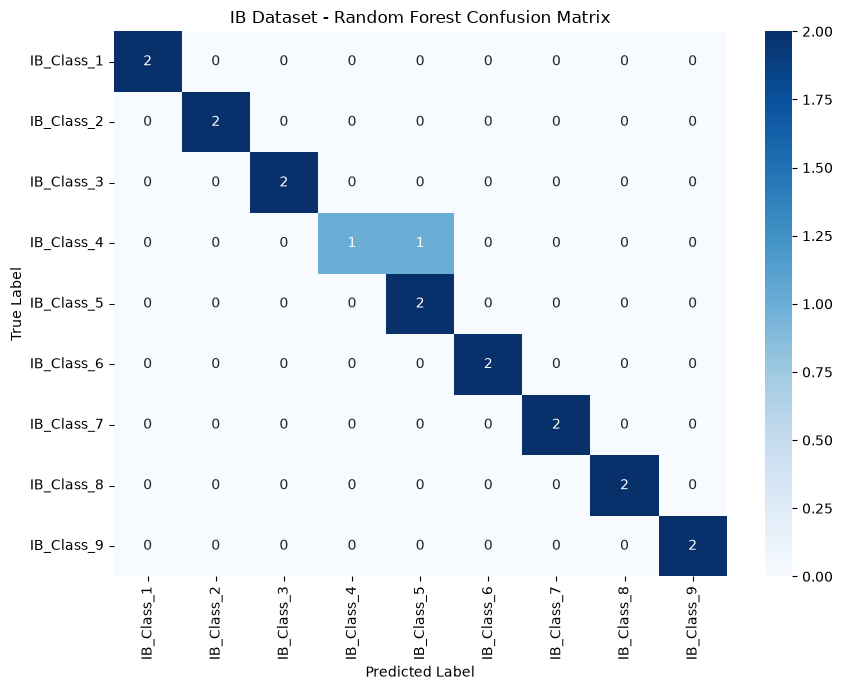

In [18]:
# ============================================
# STEP 17 - CONFUSION MATRIX VISUALIZATION
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

class_names = sorted(y_test.unique())

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("IB Dataset - Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

plt.show()

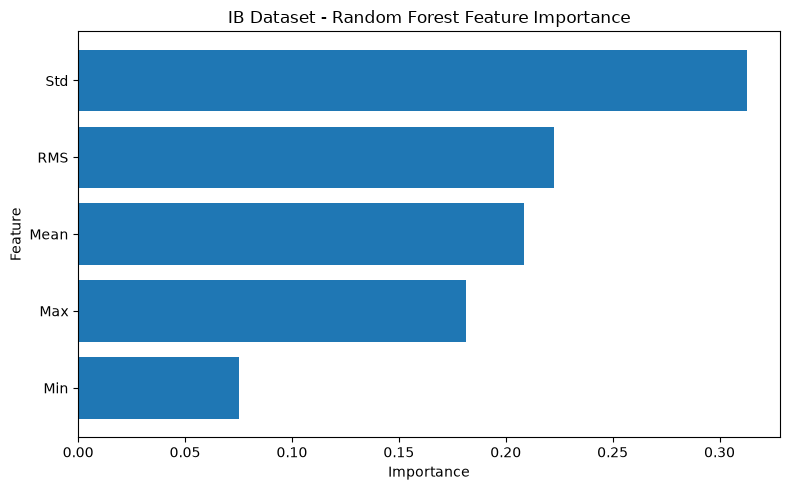

In [19]:
# ============================================
# STEP 18 - FEATURE IMPORTANCE VISUALIZATION
# ============================================

import matplotlib.pyplot as plt

# Sort features by importance
importance_df = feature_importance.sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(8, 5))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("IB Dataset - Random Forest Feature Importance")
plt.tight_layout()

plt.show()

In [22]:
# ============================================
# STEP 19 - LOAD IB RAW DATA + FFT FEATURES
# ============================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat

# IB raw dataset folder
ib_folder = r"C:\MachineHealthProject\data\IB"

data_path = os.path.join(ib_folder, "data.mat")
targets_path = os.path.join(ib_folder, "targets.mat")

# Load MATLAB files
data_mat = loadmat(data_path)
targets_mat = loadmat(targets_path)

# Extract raw data
ib_data = data_mat["Data"]
ib_targets = targets_mat["Targets"].flatten()

print("=== IB RAW DATA LOADED ===")
print("Data shape:", ib_data.shape)
print("Targets shape:", ib_targets.shape)

# Actual sampling rate of the public IB dataset
IB_SAMPLING_RATE = 17850

# FFT feature list
fft_features = []

for i in range(len(ib_data)):

    signal = ib_data[i].astype(float)

    # Remove DC component
    signal_centered = signal - np.mean(signal)

    # FFT
    fft_values = np.fft.rfft(signal_centered)

    frequencies = np.fft.rfftfreq(
        len(signal_centered),
        d=1 / IB_SAMPLING_RATE
    )

    # FFT magnitude
    magnitude = np.abs(fft_values)

    # Ignore DC component
    magnitude[0] = 0

    # Dominant frequency
    dominant_index = np.argmax(magnitude)

    dominant_frequency = frequencies[dominant_index]

    # Maximum FFT magnitude
    max_fft_magnitude = np.max(magnitude)

    # Spectral energy
    spectral_energy = np.sum(magnitude ** 2)

    # Spectral centroid
    total_magnitude = np.sum(magnitude)

    if total_magnitude > 0:
        spectral_centroid = (
            np.sum(frequencies * magnitude)
            / total_magnitude
        )
    else:
        spectral_centroid = 0

    fft_features.append({
        "Sample": i + 1,
        "Label": int(ib_targets[i]),
        "Dominant_Frequency_Hz": dominant_frequency,
        "Max_FFT_Magnitude": max_fft_magnitude,
        "Spectral_Energy": spectral_energy,
        "Spectral_Centroid_Hz": spectral_centroid
    })

# Create FFT dataframe
ib_fft_df = pd.DataFrame(fft_features)

print("\n=== IB FFT FEATURE EXTRACTION COMPLETE ===")
print("Shape:", ib_fft_df.shape)

print("\nColumns:")
print(list(ib_fft_df.columns))

print("\nFirst 10 samples:")
display(ib_fft_df.head(10))

print("\nFFT feature statistics:")
display(
    ib_fft_df[
        [
            "Dominant_Frequency_Hz",
            "Max_FFT_Magnitude",
            "Spectral_Energy",
            "Spectral_Centroid_Hz"
        ]
    ].describe().T
)

=== IB RAW DATA LOADED ===
Data shape: (178, 3571)
Targets shape: (178,)

=== IB FFT FEATURE EXTRACTION COMPLETE ===
Shape: (178, 6)

Columns:
['Sample', 'Label', 'Dominant_Frequency_Hz', 'Max_FFT_Magnitude', 'Spectral_Energy', 'Spectral_Centroid_Hz']

First 10 samples:


,Sample,Label,Dominant_Frequency_Hz,Max_FFT_Magnitude,Spectral_Energy,Spectral_Centroid_Hz
0,1,1,254.928591,12.859988,1984.034805,3010.230605
1,2,1,219.938393,15.241359,22346.389996,4364.605432
2,3,1,239.932792,8.786439,2072.425925,3004.196815
3,4,1,254.928591,10.341968,2206.073100,2928.793969
4,5,1,219.938393,8.958029,2240.539729,2920.359169
5,6,1,219.938393,18.975133,2493.610065,2892.255833
6,7,1,219.938393,14.685101,22450.096071,4369.511977
7,8,1,284.920190,11.287306,2243.407559,2895.937789
8,9,1,284.920190,10.915182,22540.717874,4363.341790
9,10,1,254.928591,13.220623,2379.304912,2873.961895



FFT feature statistics:


,count,mean,std,min,25%,50%,75%,max
Dominant_Frequency_Hz,178.0,752.120783,701.251055,29.991599,134.962195,254.928591,1504.578549,2319.350322
Max_FFT_Magnitude,178.0,96.095334,108.064220,8.481514,20.258152,42.972483,144.488259,437.931603
Spectral_Energy,178.0,147702.703681,212463.694855,1984.034805,5292.133472,54665.341024,194395.095667,895075.917292
Spectral_Centroid_Hz,178.0,3122.998036,379.149760,2465.246491,2949.890022,3072.158675,3184.819735,4380.022392


In [23]:
# ============================================
# STEP 20 - FFT FEATURE QUALITY CHECK
# ============================================

fft_numeric_features = [
    "Dominant_Frequency_Hz",
    "Max_FFT_Magnitude",
    "Spectral_Energy",
    "Spectral_Centroid_Hz"
]

print("=== FFT FEATURE QUALITY CHECK ===")

# Shape
print("\nDataset shape:")
print(ib_fft_df.shape)

# Missing values
print("\nMissing values:")
print(ib_fft_df.isnull().sum())

# Infinite values
print("\nInfinite values:")
print(
    np.isinf(
        ib_fft_df[fft_numeric_features].to_numpy()
    ).sum()
)

# Duplicate rows
print("\nDuplicate rows:")
print(ib_fft_df.duplicated().sum())

# Feature statistics
print("\n=== FFT FEATURE STATISTICS ===")
display(
    ib_fft_df[fft_numeric_features].describe().T
)

# Class distribution
print("\n=== CLASS DISTRIBUTION ===")
print(
    ib_fft_df["Label"].value_counts().sort_index()
)

=== FFT FEATURE QUALITY CHECK ===

Dataset shape:
(178, 6)

Missing values:
Sample                   0
Label                    0
Dominant_Frequency_Hz    0
Max_FFT_Magnitude        0
Spectral_Energy          0
Spectral_Centroid_Hz     0
dtype: int64

Infinite values:
0

Duplicate rows:
0

=== FFT FEATURE STATISTICS ===


,count,mean,std,min,25%,50%,75%,max
Dominant_Frequency_Hz,178.0,752.120783,701.251055,29.991599,134.962195,254.928591,1504.578549,2319.350322
Max_FFT_Magnitude,178.0,96.095334,108.064220,8.481514,20.258152,42.972483,144.488259,437.931603
Spectral_Energy,178.0,147702.703681,212463.694855,1984.034805,5292.133472,54665.341024,194395.095667,895075.917292
Spectral_Centroid_Hz,178.0,3122.998036,379.149760,2465.246491,2949.890022,3072.158675,3184.819735,4380.022392



=== CLASS DISTRIBUTION ===
Label
1    20
2    20
3    19
4    20
5    20
6    19
7    20
8    20
9    20
Name: count, dtype: int64


In [25]:
# ============================================
# STEP 21 - COMBINE TIME + FFT FEATURES
# CORRECTED VERSION
# ============================================

# Time-domain features
time_features = [
    "Mean",
    "Std",
    "Min",
    "Max",
    "RMS"
]

# Get time-domain features directly from IB processed dataframe
ib_time_features = ib_df[
    ["Sample", "Label"] + time_features
].copy()

# Get FFT features
ib_frequency_features = ib_fft_df[
    [
        "Sample",
        "Dominant_Frequency_Hz",
        "Max_FFT_Magnitude",
        "Spectral_Energy",
        "Spectral_Centroid_Hz"
    ]
].copy()

# Combine using Sample number
ib_combined_features = pd.merge(
    ib_time_features,
    ib_frequency_features,
    on="Sample",
    how="inner"
)

print("=== TIME + FREQUENCY FEATURES COMBINED ===")

print("Shape:", ib_combined_features.shape)

print("\nColumns:")
print(list(ib_combined_features.columns))

print("\nFirst 10 rows:")
display(ib_combined_features.head(10))

print("\nMissing values:")
print(ib_combined_features.isnull().sum())

print("\nDuplicate rows:")
print(ib_combined_features.duplicated().sum())

=== TIME + FREQUENCY FEATURES COMBINED ===
Shape: (178, 11)

Columns:
['Sample', 'Label', 'Mean', 'Std', 'Min', 'Max', 'RMS', 'Dominant_Frequency_Hz', 'Max_FFT_Magnitude', 'Spectral_Energy', 'Spectral_Centroid_Hz']

First 10 rows:


,Sample,Label,Mean,Std,Min,Max,RMS,Dominant_Frequency_Hz,Max_FFT_Magnitude,Spectral_Energy,Spectral_Centroid_Hz
0,1,1,0.009641,0.017640,-0.0845,0.0711,0.020103,254.928591,12.859988,1984.034805,3010.230605
1,2,1,0.010269,0.059201,-3.3340,0.1002,0.060085,219.938393,15.241359,22346.389996,4364.605432
2,3,1,0.008430,0.018029,-0.0874,0.0750,0.019902,239.932792,8.786439,2072.425925,3004.196815
3,4,1,0.044781,0.018601,-0.0495,0.1226,0.048490,254.928591,10.341968,2206.073100,2928.793969
4,5,1,0.012959,0.018746,-0.0709,0.0720,0.022789,219.938393,8.958029,2240.539729,2920.359169
5,6,1,0.017107,0.019776,-0.0894,0.0866,0.026148,219.938393,18.975133,2493.610065,2892.255833
6,7,1,-0.014943,0.059338,-3.3729,0.0594,0.061191,219.938393,14.685101,22450.096071,4369.511977
7,8,1,-0.000504,0.018758,-0.0767,0.0623,0.018764,284.920190,11.287306,2243.407559,2895.937789
8,9,1,-0.017387,0.059458,-3.3797,0.0419,0.061948,284.920190,10.915182,22540.717874,4363.341790
9,10,1,0.017285,0.019317,-0.0845,0.0944,0.025921,254.928591,13.220623,2379.304912,2873.961895



Missing values:
Sample                   0
Label                    0
Mean                     0
Std                      0
Min                      0
Max                      0
RMS                      0
Dominant_Frequency_Hz    0
Max_FFT_Magnitude        0
Spectral_Energy          0
Spectral_Centroid_Hz     0
dtype: int64

Duplicate rows:
0


In [26]:
# ============================================
# STEP 22 - 9 FEATURES: SPLIT + SCALING
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Input features
combined_features = [
    "Mean",
    "Std",
    "Min",
    "Max",
    "RMS",
    "Dominant_Frequency_Hz",
    "Max_FFT_Magnitude",
    "Spectral_Energy",
    "Spectral_Centroid_Hz"
]

# Features and target
X_combined_raw = ib_combined_features[combined_features].copy()
y_combined = ib_combined_features["Label"].copy()

print("=== DATA BEFORE SPLITTING ===")
print("Total samples:", len(X_combined_raw))
print("Number of features:", len(combined_features))

# 80% training, 20% temporary
X_train_raw2, X_temp_raw2, y_train2, y_temp2 = train_test_split(
    X_combined_raw,
    y_combined,
    test_size=0.20,
    random_state=42,
    stratify=y_combined
)

# 10% validation, 10% test
X_val_raw2, X_test_raw2, y_val2, y_test2 = train_test_split(
    X_temp_raw2,
    y_temp2,
    test_size=0.50,
    random_state=42,
    stratify=y_temp2
)

# Create scaler
combined_scaler = StandardScaler()

# Fit ONLY on training data
X_train2 = combined_scaler.fit_transform(X_train_raw2)

# Transform validation and test
X_val2 = combined_scaler.transform(X_val_raw2)
X_test2 = combined_scaler.transform(X_test_raw2)

print("\n=== SPLIT RESULTS ===")
print("Training samples:", len(X_train2))
print("Validation samples:", len(X_val2))
print("Testing samples:", len(X_test2))

print("\nFeature shapes:")
print("X_train:", X_train2.shape)
print("X_val:", X_val2.shape)
print("X_test:", X_test2.shape)

print("\n=== CLASS DISTRIBUTION ===")

print("\nTraining:")
print(y_train2.value_counts().sort_index())

print("\nValidation:")
print(y_val2.value_counts().sort_index())

print("\nTesting:")
print(y_test2.value_counts().sort_index())

print("\n=== SCALING CHECK ===")
print("Training means:")
print(X_train2.mean(axis=0))

print("\nTraining standard deviations:")
print(X_train2.std(axis=0))

=== DATA BEFORE SPLITTING ===
Total samples: 178
Number of features: 9

=== SPLIT RESULTS ===
Training samples: 142
Validation samples: 18
Testing samples: 18

Feature shapes:
X_train: (142, 9)
X_val: (18, 9)
X_test: (18, 9)

=== CLASS DISTRIBUTION ===

Training:
Label
1    16
2    16
3    15
4    16
5    16
6    15
7    16
8    16
9    16
Name: count, dtype: int64

Validation:
Label
1    2
2    2
3    2
4    2
5    2
6    2
7    2
8    2
9    2
Name: count, dtype: int64

Testing:
Label
1    2
2    2
3    2
4    2
5    2
6    2
7    2
8    2
9    2
Name: count, dtype: int64

=== SCALING CHECK ===
Training means:
[ 0.00000000e+00  7.50573312e-17 -1.12585997e-16  8.75668864e-17
  1.25095552e-17  1.65751606e-16  1.68878995e-16 -5.00382208e-17
 -3.86232517e-16]

Training standard deviations:
[1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [27]:
# ============================================
# STEP 23 - RANDOM FOREST
# TIME + FREQUENCY FEATURES
# ============================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Create Random Forest
rf_combined = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train
rf_combined.fit(
    X_train2,
    y_train2
)

print("=== RANDOM FOREST TRAINING COMPLETE ===")

# Predictions
y_train_pred2 = rf_combined.predict(X_train2)
y_val_pred2 = rf_combined.predict(X_val2)
y_test_pred2 = rf_combined.predict(X_test2)

# Accuracy
train_accuracy2 = accuracy_score(
    y_train2,
    y_train_pred2
)

val_accuracy2 = accuracy_score(
    y_val2,
    y_val_pred2
)

test_accuracy2 = accuracy_score(
    y_test2,
    y_test_pred2
)

print("\n=== ACCURACY ===")
print("Training Accuracy   :", train_accuracy2)
print("Validation Accuracy :", val_accuracy2)
print("Testing Accuracy    :", test_accuracy2)

# Classification report
print("\n=== TEST CLASSIFICATION REPORT ===")

print(
    classification_report(
        y_test2,
        y_test_pred2,
        zero_division=0
    )
)

# Confusion matrix
class_names2 = sorted(y_test2.unique())

cm2 = confusion_matrix(
    y_test2,
    y_test_pred2,
    labels=class_names2
)

print("=== TEST CONFUSION MATRIX ===")
print(cm2)

# Feature importance
feature_importance2 = pd.DataFrame({
    "Feature": combined_features,
    "Importance": rf_combined.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

print("\n=== FEATURE IMPORTANCE ===")
display(feature_importance2)

=== RANDOM FOREST TRAINING COMPLETE ===

=== ACCURACY ===
Training Accuracy   : 1.0
Validation Accuracy : 0.9444444444444444
Testing Accuracy    : 0.9444444444444444

=== TEST CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         2
           4       1.00      0.50      0.67         2
           5       0.67      1.00      0.80         2
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         2
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         2

    accuracy                           0.94        18
   macro avg       0.96      0.94      0.94        18
weighted avg       0.96      0.94      0.94        18

=== TEST CONFUSION MATRIX ===
[[2 0 0 0 0 0 0 0 0]
 [0 2 0 0 0 0 0 0 0]
 [0 0 2 0 0 0 0 0 0]


,Feature,Importance
1,Std,0.153297
6,Max_FFT_Magnitude,0.142135
7,Spectral_Energy,0.140055
3,Max,0.128466
4,RMS,0.128140
0,Mean,0.117324
5,Dominant_Frequency_Hz,0.107859
8,Spectral_Centroid_Hz,0.051459
2,Min,0.031266


In [28]:
# ============================================
# STEP 24 - SAVE COMBINED FEATURE DATASET
# ============================================

import os

processed_folder = r"C:\MachineHealthProject\processed"

os.makedirs(
    processed_folder,
    exist_ok=True
)

combined_feature_path = os.path.join(
    processed_folder,
    "IB_Time_Frequency_Features.csv"
)

ib_combined_features.to_csv(
    combined_feature_path,
    index=False
)

print("=== COMBINED FEATURE DATASET SAVED ===")
print("File:", combined_feature_path)

# Verify saved file
saved_check = pd.read_csv(
    combined_feature_path
)

print("\n=== SAVED FILE VERIFICATION ===")
print("Shape:", saved_check.shape)

print("\nColumns:")
print(list(saved_check.columns))

print("\nMissing values:")
print(saved_check.isnull().sum().sum())

print("\nFirst 5 rows:")
display(saved_check.head())

=== COMBINED FEATURE DATASET SAVED ===
File: C:\MachineHealthProject\processed\IB_Time_Frequency_Features.csv

=== SAVED FILE VERIFICATION ===
Shape: (178, 11)

Columns:
['Sample', 'Label', 'Mean', 'Std', 'Min', 'Max', 'RMS', 'Dominant_Frequency_Hz', 'Max_FFT_Magnitude', 'Spectral_Energy', 'Spectral_Centroid_Hz']

Missing values:
0

First 5 rows:


,Sample,Label,Mean,Std,Min,Max,RMS,Dominant_Frequency_Hz,Max_FFT_Magnitude,Spectral_Energy,Spectral_Centroid_Hz
0,1,1,0.009641,0.017640,-0.0845,0.0711,0.020103,254.928591,12.859988,1984.034805,3010.230605
1,2,1,0.010269,0.059201,-3.3340,0.1002,0.060085,219.938393,15.241359,22346.389996,4364.605432
2,3,1,0.008430,0.018029,-0.0874,0.0750,0.019902,239.932792,8.786439,2072.425925,3004.196815
3,4,1,0.044781,0.018601,-0.0495,0.1226,0.048490,254.928591,10.341968,2206.073100,2928.793969
4,5,1,0.012959,0.018746,-0.0709,0.0720,0.022789,219.938393,8.958029,2240.539729,2920.359169


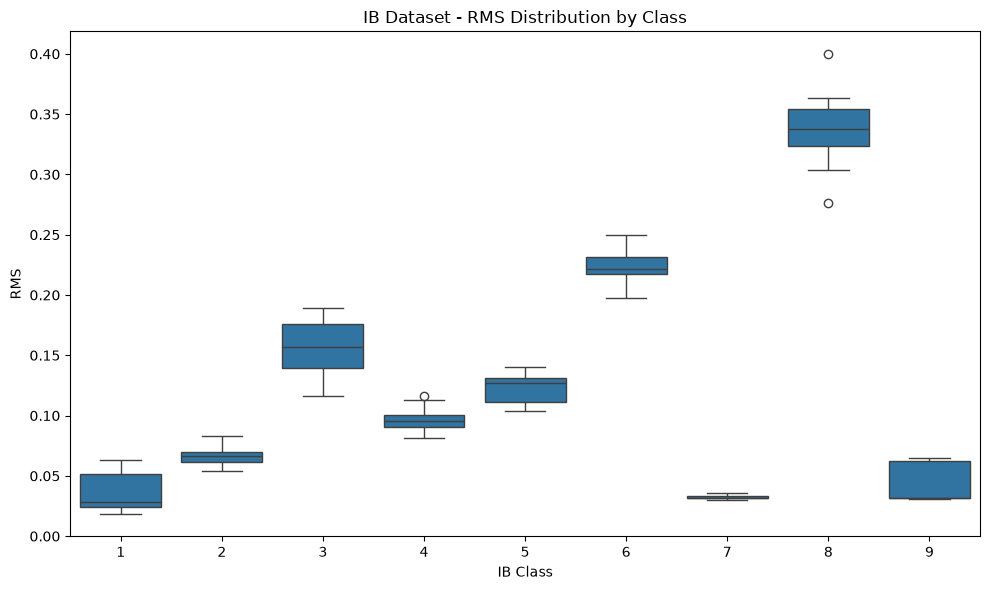

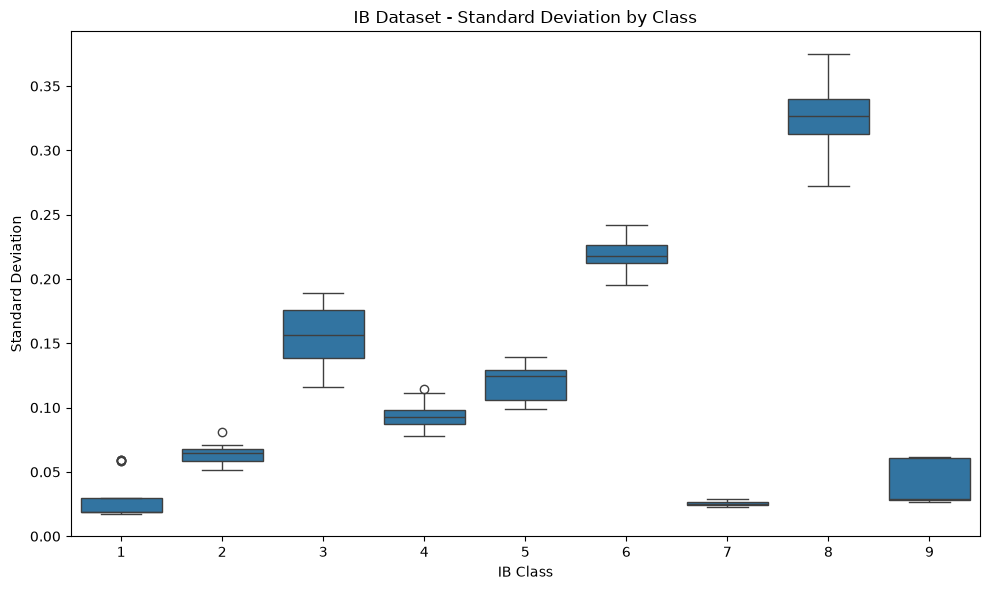

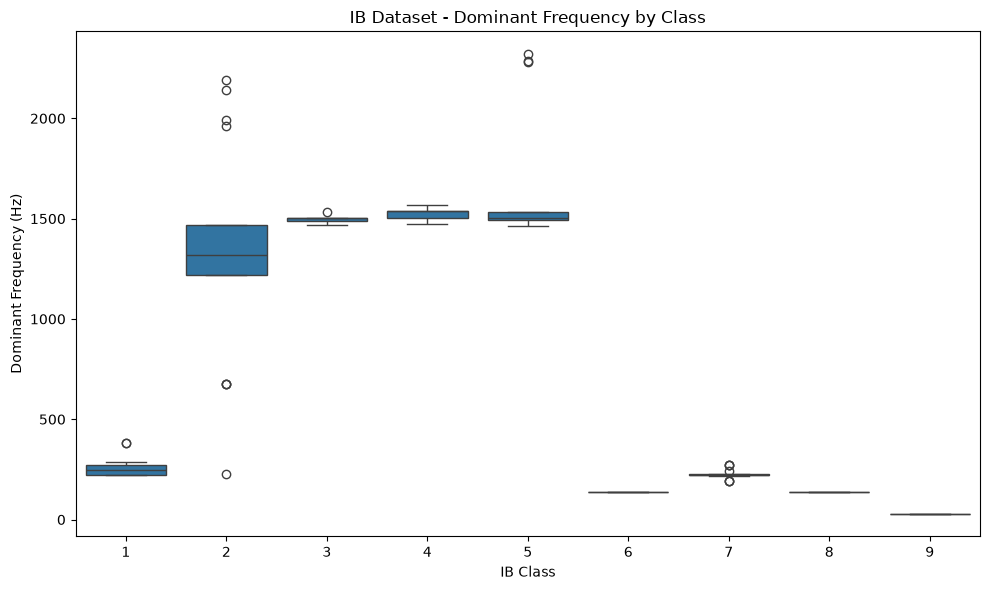

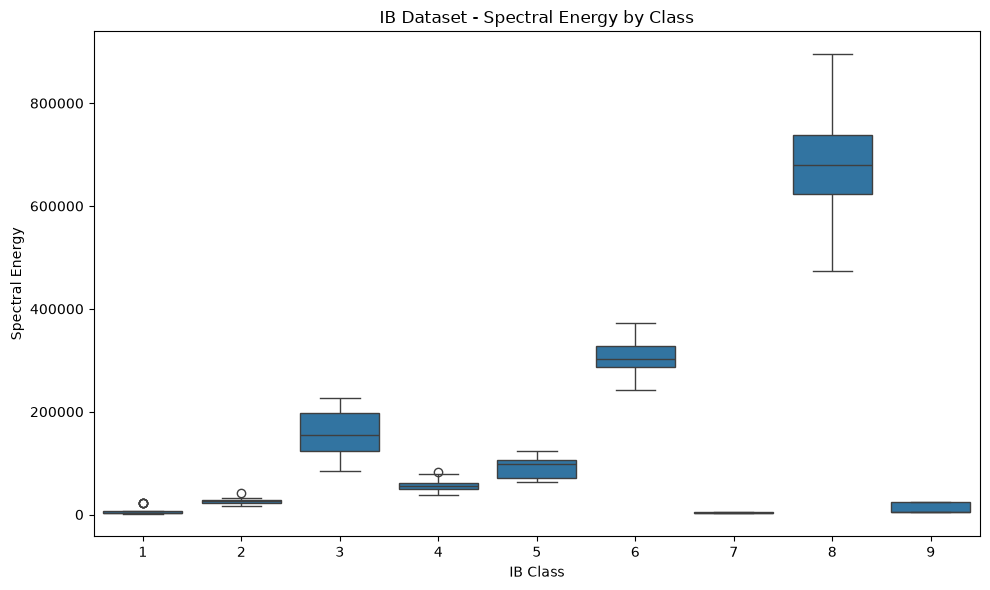

In [29]:
# ============================================
# STEP 25 - IB FEATURE VISUALIZATION
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------
# 1. RMS distribution by class
# --------------------------------------------

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=ib_combined_features,
    x="Label",
    y="RMS"
)

plt.title("IB Dataset - RMS Distribution by Class")
plt.xlabel("IB Class")
plt.ylabel("RMS")
plt.tight_layout()
plt.show()


# --------------------------------------------
# 2. Standard deviation by class
# --------------------------------------------

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=ib_combined_features,
    x="Label",
    y="Std"
)

plt.title("IB Dataset - Standard Deviation by Class")
plt.xlabel("IB Class")
plt.ylabel("Standard Deviation")
plt.tight_layout()
plt.show()


# --------------------------------------------
# 3. Dominant frequency by class
# --------------------------------------------

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=ib_combined_features,
    x="Label",
    y="Dominant_Frequency_Hz"
)

plt.title("IB Dataset - Dominant Frequency by Class")
plt.xlabel("IB Class")
plt.ylabel("Dominant Frequency (Hz)")
plt.tight_layout()
plt.show()


# --------------------------------------------
# 4. Spectral energy by class
# --------------------------------------------

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=ib_combined_features,
    x="Label",
    y="Spectral_Energy"
)

plt.title("IB Dataset - Spectral Energy by Class")
plt.xlabel("IB Class")
plt.ylabel("Spectral Energy")
plt.tight_layout()
plt.show()

=== CORRELATION MATRIX ===


,Mean,Std,Min,Max,RMS,Dominant_Frequency_Hz,Max_FFT_Magnitude,Spectral_Energy,Spectral_Centroid_Hz
Mean,1.000000,-0.905417,0.433455,-0.455274,-0.912426,0.417628,-0.955339,-0.950584,0.064568
Std,-0.905417,1.000000,-0.516770,0.711744,0.999136,-0.097541,0.973573,0.961056,-0.032411
Min,0.433455,-0.516770,1.000000,-0.316155,-0.505940,0.040288,-0.439416,-0.433573,-0.750778
Max,-0.455274,0.711744,-0.316155,1.000000,0.699266,0.504118,0.607504,0.599533,-0.089648
RMS,-0.912426,0.999136,-0.505940,0.699266,1.000000,-0.118047,0.978177,0.968995,-0.042609
Dominant_Frequency_Hz,0.417628,-0.097541,0.040288,0.504118,-0.118047,1.000000,-0.257123,-0.271054,0.045108
Max_FFT_Magnitude,-0.955339,0.973573,-0.439416,0.607504,0.978177,-0.257123,1.000000,0.985013,-0.112590
Spectral_Energy,-0.950584,0.961056,-0.433573,0.599533,0.968995,-0.271054,0.985013,1.000000,-0.104005
Spectral_Centroid_Hz,0.064568,-0.032411,-0.750778,-0.089648,-0.042609,0.045108,-0.112590,-0.104005,1.000000


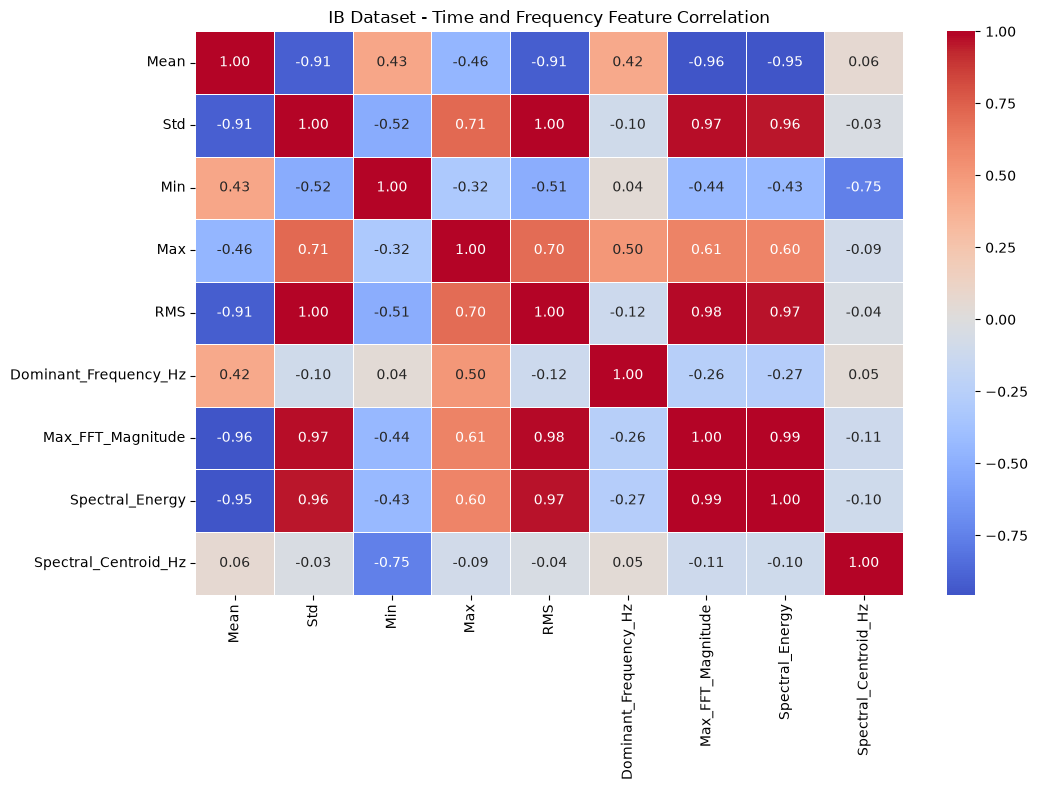

In [30]:
# ============================================
# STEP 26 - CORRELATION HEATMAP
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# Select the 9 numerical features
correlation_features = [
    "Mean",
    "Std",
    "Min",
    "Max",
    "RMS",
    "Dominant_Frequency_Hz",
    "Max_FFT_Magnitude",
    "Spectral_Energy",
    "Spectral_Centroid_Hz"
]

# Calculate correlation matrix
correlation_matrix = ib_combined_features[
    correlation_features
].corr()

print("=== CORRELATION MATRIX ===")
display(correlation_matrix)

# Plot heatmap
plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("IB Dataset - Time and Frequency Feature Correlation")
plt.tight_layout()

plt.show()

In [31]:
# ============================================
# STEP 27 - MODEL COMPARISON
# ============================================

model_comparison = pd.DataFrame({
    "Model": [
        "Random Forest - Time Domain",
        "Random Forest - Time + Frequency"
    ],
    "Number_of_Features": [
        5,
        9
    ],
    "Training_Accuracy": [
        train_accuracy,
        train_accuracy2
    ],
    "Validation_Accuracy": [
        val_accuracy,
        val_accuracy2
    ],
    "Test_Accuracy": [
        test_accuracy,
        test_accuracy2
    ]
})

print("=== MODEL COMPARISON ===")
display(model_comparison)

print("\n=== TEST ACCURACY DIFFERENCE ===")

accuracy_difference = (
    test_accuracy2 - test_accuracy
)

print(
    "Difference:",
    accuracy_difference
)

print(
    "Difference (%):",
    accuracy_difference * 100
)

=== MODEL COMPARISON ===


,Model,Number_of_Features,Training_Accuracy,Validation_Accuracy,Test_Accuracy
0,Random Forest - Time Domain,5,1.0,0.944444,0.944444
1,Random Forest - Time + Frequency,9,1.0,0.944444,0.944444



=== TEST ACCURACY DIFFERENCE ===
Difference: 0.0
Difference (%): 0.0


In [32]:
# ============================================
# STEP 28 - SAVE MODEL RESULTS
# ============================================

import os

processed_folder = r"C:\MachineHealthProject\processed"

# --------------------------------------------
# Save model comparison
# --------------------------------------------

comparison_path = os.path.join(
    processed_folder,
    "IB_Model_Comparison.csv"
)

model_comparison.to_csv(
    comparison_path,
    index=False
)

# --------------------------------------------
# Save feature importance
# --------------------------------------------

importance_path = os.path.join(
    processed_folder,
    "IB_Feature_Importance.csv"
)

feature_importance2.to_csv(
    importance_path,
    index=False
)

# --------------------------------------------
# Verify files
# --------------------------------------------

print("=== MODEL RESULTS SAVED ===")

print("\nModel comparison:")
print(comparison_path)

print("\nFeature importance:")
print(importance_path)

print("\n=== VERIFICATION ===")

comparison_check = pd.read_csv(comparison_path)
importance_check = pd.read_csv(importance_path)

print("\nModel comparison shape:",
      comparison_check.shape)

print("Feature importance shape:",
      importance_check.shape)

print("\nModel comparison:")
display(comparison_check)

print("\nFeature importance:")
display(importance_check)

=== MODEL RESULTS SAVED ===

Model comparison:
C:\MachineHealthProject\processed\IB_Model_Comparison.csv

Feature importance:
C:\MachineHealthProject\processed\IB_Feature_Importance.csv

=== VERIFICATION ===

Model comparison shape: (2, 5)
Feature importance shape: (9, 2)

Model comparison:


,Model,Number_of_Features,Training_Accuracy,Validation_Accuracy,Test_Accuracy
0,Random Forest - Time Domain,5,1.0,0.944444,0.944444
1,Random Forest - Time + Frequency,9,1.0,0.944444,0.944444



Feature importance:


,Feature,Importance
0,Std,0.153297
1,Max_FFT_Magnitude,0.142135
2,Spectral_Energy,0.140055
3,Max,0.128466
4,RMS,0.128140
5,Mean,0.117324
6,Dominant_Frequency_Hz,0.107859
7,Spectral_Centroid_Hz,0.051459
8,Min,0.031266


In [33]:
# ============================================
# STEP 29 - 5-FOLD CROSS-VALIDATION
# ============================================

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier

# Use the complete 9-feature dataset
X_cv = ib_combined_features[combined_features].copy()
y_cv = ib_combined_features["Label"].copy()

# 5-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Random Forest for cross-validation
rf_cv = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Calculate cross-validation accuracy
cv_scores = cross_val_score(
    rf_cv,
    X_cv,
    y_cv,
    cv=cv,
    scoring="accuracy"
)

print("=== 5-FOLD CROSS-VALIDATION ===")

print("\nFold accuracies:")

for i, score in enumerate(cv_scores, start=1):
    print(
        f"Fold {i}: {score:.4f} "
        f"({score * 100:.2f}%)"
    )

print("\nMean CV Accuracy:")
print(
    f"{cv_scores.mean():.4f} "
    f"({cv_scores.mean() * 100:.2f}%)"
)

print("\nStandard Deviation:")
print(
    f"{cv_scores.std():.4f}"
    f" ({cv_scores.std() * 100:.2f} percentage points)"
)

print("\nMinimum Fold Accuracy:")
print(
    f"{cv_scores.min():.4f} "
    f"({cv_scores.min() * 100:.2f}%)"
)

print("\nMaximum Fold Accuracy:")
print(
    f"{cv_scores.max():.4f} "
    f"({cv_scores.max() * 100:.2f}%)"
)

=== 5-FOLD CROSS-VALIDATION ===

Fold accuracies:
Fold 1: 1.0000 (100.00%)
Fold 2: 0.9722 (97.22%)
Fold 3: 0.9444 (94.44%)
Fold 4: 0.9714 (97.14%)
Fold 5: 1.0000 (100.00%)

Mean CV Accuracy:
0.9776 (97.76%)

Standard Deviation:
0.0208 (2.08 percentage points)

Minimum Fold Accuracy:
0.9444 (94.44%)

Maximum Fold Accuracy:
1.0000 (100.00%)


In [34]:
# ============================================
# STEP 30 - FINAL MODEL PERFORMANCE SUMMARY
# ============================================

# Calculate CV statistics from Step 29
cv_mean = cv_scores.mean()
cv_std = cv_scores.std()

# Create summary table
final_results = pd.DataFrame({
    "Evaluation": [
        "Training Accuracy",
        "Validation Accuracy",
        "Test Accuracy",
        "5-Fold CV Mean Accuracy"
    ],
    "Accuracy": [
        train_accuracy2,
        val_accuracy2,
        test_accuracy2,
        cv_mean
    ]
})

print("=== FINAL MODEL PERFORMANCE ===")
display(final_results)

print("\n=== CROSS-VALIDATION SUMMARY ===")
print(f"Mean CV Accuracy : {cv_mean:.4f} ({cv_mean * 100:.2f}%)")
print(f"CV Std Deviation : {cv_std:.4f} ({cv_std * 100:.2f} percentage points)")

print("\n=== TEST VS CV ===")
print(f"Test Accuracy    : {test_accuracy2 * 100:.2f}%")
print(f"CV Mean Accuracy : {cv_mean * 100:.2f}%")

difference_cv_test = test_accuracy2 - cv_mean

print(
    f"Difference       : {difference_cv_test * 100:.2f} percentage points"
)

=== FINAL MODEL PERFORMANCE ===


,Evaluation,Accuracy
0,Training Accuracy,1.000000
1,Validation Accuracy,0.944444
2,Test Accuracy,0.944444
3,5-Fold CV Mean Accuracy,0.977619



=== CROSS-VALIDATION SUMMARY ===
Mean CV Accuracy : 0.9776 (97.76%)
CV Std Deviation : 0.0208 (2.08 percentage points)

=== TEST VS CV ===
Test Accuracy    : 94.44%
CV Mean Accuracy : 97.76%
Difference       : -3.32 percentage points


In [35]:
# ============================================
# STEP 31 - CROSS-VALIDATION STABILITY CHECK
# ============================================

print("=== 5-FOLD CROSS-VALIDATION DETAILS ===")

for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i}: {score * 100:.2f}%")

print("\n=== SUMMARY ===")
print(f"Mean Accuracy : {cv_scores.mean() * 100:.2f}%")
print(f"Std Deviation : {cv_scores.std() * 100:.2f}%")
print(f"Minimum       : {cv_scores.min() * 100:.2f}%")
print(f"Maximum       : {cv_scores.max() * 100:.2f}%")

print("\n=== INTERPRETATION ===")

if cv_scores.std() < 0.03:
    print("Model performance is relatively stable across folds.")
else:
    print("Model performance shows noticeable variation across folds.")

if abs(cv_scores.mean() - test_accuracy2) < 0.05:
    print("CV accuracy and test accuracy are reasonably close.")
else:
    print("There is a noticeable difference between CV and test accuracy.")

=== 5-FOLD CROSS-VALIDATION DETAILS ===
Fold 1: 100.00%
Fold 2: 97.22%
Fold 3: 94.44%
Fold 4: 97.14%
Fold 5: 100.00%

=== SUMMARY ===
Mean Accuracy : 97.76%
Std Deviation : 2.08%
Minimum       : 94.44%
Maximum       : 100.00%

=== INTERPRETATION ===
Model performance is relatively stable across folds.
CV accuracy and test accuracy are reasonably close.


In [36]:
# ============================================
# STEP 32 - SAVE COMPLETE MODEL RESULTS
# ============================================

import pandas as pd
import os

# Create final evaluation summary
model_results = pd.DataFrame({
    "Metric": [
        "Training Accuracy",
        "Validation Accuracy",
        "Test Accuracy",
        "5-Fold CV Mean Accuracy",
        "5-Fold CV Std Deviation",
        "Minimum CV Accuracy",
        "Maximum CV Accuracy"
    ],
    "Value": [
        train_accuracy2,
        val_accuracy2,
        test_accuracy2,
        cv_scores.mean(),
        cv_scores.std(),
        cv_scores.min(),
        cv_scores.max()
    ],
    "Percentage": [
        train_accuracy2 * 100,
        val_accuracy2 * 100,
        test_accuracy2 * 100,
        cv_scores.mean() * 100,
        cv_scores.std() * 100,
        cv_scores.min() * 100,
        cv_scores.max() * 100
    ]
})

# Save results
results_path = r"C:\MachineHealthProject\processed\IB_Final_Model_Results.csv"

model_results.to_csv(
    results_path,
    index=False
)

print("=== FINAL MODEL RESULTS ===")
display(model_results)

print("\nFile saved successfully:")
print(results_path)

print("\n=== FINAL RESULT ===")
print(
    f"Test Accuracy: {test_accuracy2 * 100:.2f}%"
)

print(
    f"5-Fold CV Accuracy: "
    f"{cv_scores.mean() * 100:.2f}% ± "
    f"{cv_scores.std() * 100:.2f}%"
)

=== FINAL MODEL RESULTS ===


,Metric,Value,Percentage
0,Training Accuracy,1.000000,100.000000
1,Validation Accuracy,0.944444,94.444444
2,Test Accuracy,0.944444,94.444444
3,5-Fold CV Mean Accuracy,0.977619,97.761905
4,5-Fold CV Std Deviation,0.020832,2.083178
5,Minimum CV Accuracy,0.944444,94.444444
6,Maximum CV Accuracy,1.000000,100.000000



File saved successfully:
C:\MachineHealthProject\processed\IB_Final_Model_Results.csv

=== FINAL RESULT ===
Test Accuracy: 94.44%
5-Fold CV Accuracy: 97.76% ± 2.08%


In [38]:
# ============================================
# STEP 33 - CLASS-WISE PERFORMANCE EVALUATION
# ============================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# Create the Random Forest model again
rf2 = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train using the already prepared training data
rf2.fit(
    X_train,
    y_train
)

# Predict on the held-out test set
y_test_pred = rf2.predict(
    X_test
)

# Classification report
print("=== CLASS-WISE CLASSIFICATION REPORT ===")

print(
    classification_report(
        y_test,
        y_test_pred,
        digits=4,
        zero_division=0
    )
)

# Confusion matrix
cm = confusion_matrix(
    y_test,
    y_test_pred
)

print("=== CONFUSION MATRIX ===")
print(cm)

# Overall accuracy
test_acc = accuracy_score(
    y_test,
    y_test_pred
)

print("\n=== TEST ACCURACY ===")
print(
    f"{test_acc:.4f} "
    f"({test_acc * 100:.2f}%)"
)

=== CLASS-WISE CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

  IB_Class_1     1.0000    1.0000    1.0000         2
  IB_Class_2     1.0000    1.0000    1.0000         2
  IB_Class_3     1.0000    1.0000    1.0000         2
  IB_Class_4     1.0000    0.5000    0.6667         2
  IB_Class_5     0.6667    1.0000    0.8000         2
  IB_Class_6     1.0000    1.0000    1.0000         2
  IB_Class_7     1.0000    1.0000    1.0000         2
  IB_Class_8     1.0000    1.0000    1.0000         2
  IB_Class_9     1.0000    1.0000    1.0000         2

    accuracy                         0.9444        18
   macro avg     0.9630    0.9444    0.9407        18
weighted avg     0.9630    0.9444    0.9407        18

=== CONFUSION MATRIX ===
[[2 0 0 0 0 0 0 0 0]
 [0 2 0 0 0 0 0 0 0]
 [0 0 2 0 0 0 0 0 0]
 [0 0 0 1 1 0 0 0 0]
 [0 0 0 0 2 0 0 0 0]
 [0 0 0 0 0 2 0 0 0]
 [0 0 0 0 0 0 2 0 0]
 [0 0 0 0 0 0 0 2 0]
 [0 0 0 0 0 0 0 0 2]]

=== TEST ACCURACY ===
0.9444 (94.44%)


In [40]:
# ============================================
# STEP 34 - SAVE CLASS-WISE RESULTS
# ============================================

from sklearn.metrics import classification_report
import pandas as pd
import os

# Generate classification report
report_dict = classification_report(
    y_test,
    y_test_pred,
    output_dict=True,
    zero_division=0
)

# Convert to DataFrame
class_results = pd.DataFrame(report_dict).transpose()

# Correct Windows path
class_results_path = os.path.join(
    r"C:\MachineHealthProject\processed",
    "IB_Classwise_Performance.csv"
)

# Save CSV
class_results.to_csv(
    class_results_path
)

print("=== CLASS-WISE RESULTS ===")
display(class_results)

print("\nFile saved successfully:")
print(class_results_path)

=== CLASS-WISE RESULTS ===


,precision,recall,f1-score,support
IB_Class_1,1.000000,1.000000,1.000000,2.000000
IB_Class_2,1.000000,1.000000,1.000000,2.000000
IB_Class_3,1.000000,1.000000,1.000000,2.000000
IB_Class_4,1.000000,0.500000,0.666667,2.000000
IB_Class_5,0.666667,1.000000,0.800000,2.000000
IB_Class_6,1.000000,1.000000,1.000000,2.000000
IB_Class_7,1.000000,1.000000,1.000000,2.000000
IB_Class_8,1.000000,1.000000,1.000000,2.000000
IB_Class_9,1.000000,1.000000,1.000000,2.000000
accuracy,0.944444,0.944444,0.944444,0.944444



File saved successfully:
C:\MachineHealthProject\processed\IB_Classwise_Performance.csv


In [41]:
# ============================================
# STEP 35 - 5-FOLD CV COMPARISON
# 5 FEATURES vs 9 FEATURES
# ============================================

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# --------------------------------------------
# 1. Five time-domain features
# --------------------------------------------

features_5 = [
    "Mean",
    "Std",
    "Min",
    "Max",
    "RMS"
]

X_5 = ib_combined_features[features_5]
y_5 = ib_combined_features["Label"]


# --------------------------------------------
# 2. Nine time + frequency features
# --------------------------------------------

features_9 = [
    "Mean",
    "Std",
    "Min",
    "Max",
    "RMS",
    "Dominant_Frequency_Hz",
    "Max_FFT_Magnitude",
    "Spectral_Energy",
    "Spectral_Centroid_Hz"
]

X_9 = ib_combined_features[features_9]
y_9 = ib_combined_features["Label"]


# --------------------------------------------
# 3. Same 5-fold split for fair comparison
# --------------------------------------------

cv_compare = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# --------------------------------------------
# 4. Random Forest - 5 features
# --------------------------------------------

rf_5 = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

scores_5 = cross_val_score(
    rf_5,
    X_5,
    y_5,
    cv=cv_compare,
    scoring="accuracy"
)


# --------------------------------------------
# 5. Random Forest - 9 features
# --------------------------------------------

rf_9 = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

scores_9 = cross_val_score(
    rf_9,
    X_9,
    y_9,
    cv=cv_compare,
    scoring="accuracy"
)


# --------------------------------------------
# 6. Display fold results
# --------------------------------------------

print("=== 5-FOLD CROSS-VALIDATION COMPARISON ===")

for i in range(5):
    print(
        f"Fold {i + 1}: "
        f"5 Features = {scores_5[i] * 100:.2f}% | "
        f"9 Features = {scores_9[i] * 100:.2f}%"
    )


# --------------------------------------------
# 7. Summary
# --------------------------------------------

comparison = pd.DataFrame({
    "Model": [
        "Random Forest - 5 Features",
        "Random Forest - 9 Features"
    ],
    "Mean CV Accuracy": [
        scores_5.mean(),
        scores_9.mean()
    ],
    "CV Std Deviation": [
        scores_5.std(),
        scores_9.std()
    ],
    "Minimum Accuracy": [
        scores_5.min(),
        scores_9.min()
    ],
    "Maximum Accuracy": [
        scores_5.max(),
        scores_9.max()
    ]
})

print("\n=== MODEL COMPARISON ===")

display(comparison)

=== 5-FOLD CROSS-VALIDATION COMPARISON ===
Fold 1: 5 Features = 94.44% | 9 Features = 100.00%
Fold 2: 5 Features = 97.22% | 9 Features = 97.22%
Fold 3: 5 Features = 94.44% | 9 Features = 94.44%
Fold 4: 5 Features = 91.43% | 9 Features = 97.14%
Fold 5: 5 Features = 94.29% | 9 Features = 100.00%

=== MODEL COMPARISON ===


,Model,Mean CV Accuracy,CV Std Deviation,Minimum Accuracy,Maximum Accuracy
0,Random Forest - 5 Features,0.943651,0.018333,0.914286,0.972222
1,Random Forest - 9 Features,0.977619,0.020832,0.944444,1.000000


In [42]:
# ============================================
# STEP 36 - SAVE 5 vs 9 FEATURE COMPARISON
# ============================================

import pandas as pd
import os

feature_comparison = pd.DataFrame({
    "Model": [
        "Random Forest - 5 Time-Domain Features",
        "Random Forest - 9 Time + FFT Features"
    ],
    "Mean_CV_Accuracy": [
        scores_5.mean(),
        scores_9.mean()
    ],
    "CV_Std_Deviation": [
        scores_5.std(),
        scores_9.std()
    ],
    "Minimum_CV_Accuracy": [
        scores_5.min(),
        scores_9.min()
    ],
    "Maximum_CV_Accuracy": [
        scores_5.max(),
        scores_9.max()
    ]
})

# Calculate improvement
improvement = (
    scores_9.mean() - scores_5.mean()
)

print("=== FEATURE COMPARISON ===")
display(feature_comparison)

print(
    f"\nImprovement from adding FFT features: "
    f"{improvement * 100:.2f} percentage points"
)

# Save
comparison_path = os.path.join(
    r"C:\MachineHealthProject\processed",
    "IB_5_vs_9_Feature_CV_Comparison.csv"
)

feature_comparison.to_csv(
    comparison_path,
    index=False
)

print("\nFile saved successfully:")
print(comparison_path)

=== FEATURE COMPARISON ===


,Model,Mean_CV_Accuracy,CV_Std_Deviation,Minimum_CV_Accuracy,Maximum_CV_Accuracy
0,Random Forest - 5 Time-Domain Features,0.943651,0.018333,0.914286,0.972222
1,Random Forest - 9 Time + FFT Features,0.977619,0.020832,0.944444,1.000000



Improvement from adding FFT features: 3.40 percentage points

File saved successfully:
C:\MachineHealthProject\processed\IB_5_vs_9_Feature_CV_Comparison.csv


In [43]:
# ============================================
# STEP 37 - FINAL FEATURE IMPORTANCE
# ============================================

from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import os

# Final 9 features
final_features = [
    "Mean",
    "Std",
    "Min",
    "Max",
    "RMS",
    "Dominant_Frequency_Hz",
    "Max_FFT_Magnitude",
    "Spectral_Energy",
    "Spectral_Centroid_Hz"
]

X_final = ib_combined_features[final_features]
y_final = ib_combined_features["Label"]

# Train final Random Forest on all available IB samples
rf_final = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_final.fit(
    X_final,
    y_final
)

# Extract feature importance
importance_df = pd.DataFrame({
    "Feature": final_features,
    "Importance": rf_final.feature_importances_
})

# Sort from highest to lowest
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("=== FINAL FEATURE IMPORTANCE ===")
display(importance_df)

# Save results
importance_path = os.path.join(
    r"C:\MachineHealthProject\processed",
    "IB_Final_Feature_Importance.csv"
)

importance_df.to_csv(
    importance_path,
    index=False
)

print("\nFile saved successfully:")
print(importance_path)

=== FINAL FEATURE IMPORTANCE ===


,Feature,Importance
0,Spectral_Energy,0.154163
1,Std,0.146027
2,Max_FFT_Magnitude,0.139889
3,Max,0.127857
4,Mean,0.116841
5,Dominant_Frequency_Hz,0.107765
6,RMS,0.103366
7,Spectral_Centroid_Hz,0.068208
8,Min,0.035884



File saved successfully:
C:\MachineHealthProject\processed\IB_Final_Feature_Importance.csv


In [44]:
# ============================================
# STEP 38 - FEATURE IMPORTANCE ANALYSIS
# ============================================

print("=== FEATURE IMPORTANCE RANKING ===")

display(importance_df)

# Top 5 features
top_5_features = importance_df.head(5)

print("\n=== TOP 5 FEATURES ===")

for i, row in top_5_features.iterrows():
    print(
        f"{i + 1}. {row['Feature']} "
        f"-> {row['Importance']:.6f} "
        f"({row['Importance'] * 100:.2f}%)"
    )

# Check total importance
print("\n=== TOTAL FEATURE IMPORTANCE ===")
print(
    f"{importance_df['Importance'].sum():.6f}"
)

=== FEATURE IMPORTANCE RANKING ===


,Feature,Importance
0,Spectral_Energy,0.154163
1,Std,0.146027
2,Max_FFT_Magnitude,0.139889
3,Max,0.127857
4,Mean,0.116841
5,Dominant_Frequency_Hz,0.107765
6,RMS,0.103366
7,Spectral_Centroid_Hz,0.068208
8,Min,0.035884



=== TOP 5 FEATURES ===
1. Spectral_Energy -> 0.154163 (15.42%)
2. Std -> 0.146027 (14.60%)
3. Max_FFT_Magnitude -> 0.139889 (13.99%)
4. Max -> 0.127857 (12.79%)
5. Mean -> 0.116841 (11.68%)

=== TOTAL FEATURE IMPORTANCE ===
1.000000


In [45]:
# ============================================
# STEP 39 - FINAL MODEL SELECTION
# ============================================

import pandas as pd
import os

# Performance values
five_feature_cv = scores_5.mean()
nine_feature_cv = scores_9.mean()

improvement = nine_feature_cv - five_feature_cv

# Final selected model
final_model_name = "Random Forest - 9 Time + FFT Features"

selected_features = [
    "Mean",
    "Std",
    "Min",
    "Max",
    "RMS",
    "Dominant_Frequency_Hz",
    "Max_FFT_Magnitude",
    "Spectral_Energy",
    "Spectral_Centroid_Hz"
]

# Create final selection summary
final_selection = pd.DataFrame({
    "Item": [
        "Selected Model",
        "Number of Features",
        "Feature Type",
        "Test Accuracy",
        "5-Fold CV Mean Accuracy",
        "5-Fold CV Std Deviation",
        "CV Minimum Accuracy",
        "CV Maximum Accuracy",
        "Improvement Over 5-Feature Model"
    ],
    "Value": [
        final_model_name,
        len(selected_features),
        "Time-domain + Frequency-domain FFT",
        test_accuracy2,
        nine_feature_cv,
        scores_9.std(),
        scores_9.min(),
        scores_9.max(),
        improvement
    ]
})

print("=== FINAL MODEL SELECTION ===")
display(final_selection)

print("\n=== SELECTED FEATURES ===")

for i, feature in enumerate(selected_features, start=1):
    print(f"{i}. {feature}")

print("\n=== FINAL DECISION ===")
print(
    f"Selected model: {final_model_name}"
)

print(
    f"5-Fold CV accuracy: "
    f"{nine_feature_cv * 100:.2f}%"
)

print(
    f"Test accuracy: "
    f"{test_accuracy2 * 100:.2f}%"
)

# Save final selection
selection_path = os.path.join(
    r"C:\MachineHealthProject\processed",
    "IB_Final_Model_Selection.csv"
)

final_selection.to_csv(
    selection_path,
    index=False
)

print("\nFile saved successfully:")
print(selection_path)

=== FINAL MODEL SELECTION ===


,Item,Value
0,Selected Model,Random Forest - 9 Time + FFT Features
1,Number of Features,9
2,Feature Type,Time-domain + Frequency-domain FFT
3,Test Accuracy,0.944444
4,5-Fold CV Mean Accuracy,0.977619
5,5-Fold CV Std Deviation,0.020832
6,CV Minimum Accuracy,0.944444
7,CV Maximum Accuracy,1.0
8,Improvement Over 5-Feature Model,0.033968



=== SELECTED FEATURES ===
1. Mean
2. Std
3. Min
4. Max
5. RMS
6. Dominant_Frequency_Hz
7. Max_FFT_Magnitude
8. Spectral_Energy
9. Spectral_Centroid_Hz

=== FINAL DECISION ===
Selected model: Random Forest - 9 Time + FFT Features
5-Fold CV accuracy: 97.76%
Test accuracy: 94.44%

File saved successfully:
C:\MachineHealthProject\processed\IB_Final_Model_Selection.csv


In [46]:
# ============================================
# STEP 40 - FINAL IB MODEL EVALUATION SUMMARY
# ============================================

import pandas as pd
import os

# Final evaluation values
final_results = pd.DataFrame({
    "Metric": [
        "Dataset",
        "Total Samples",
        "Number of Classes",
        "Features Used",
        "Model",
        "Training Accuracy",
        "Validation Accuracy",
        "Test Accuracy",
        "5-Fold CV Mean Accuracy",
        "5-Fold CV Standard Deviation",
        "Minimum CV Accuracy",
        "Maximum CV Accuracy",
        "5-Feature CV Accuracy",
        "9-Feature CV Accuracy",
        "Improvement from FFT Features"
    ],
    "Value": [
        "Public Intelligent Bearing (IB) Dataset",
        len(ib_combined_features),
        ib_combined_features["Label"].nunique(),
        9,
        "Random Forest (100 Trees)",
        1.000000,
        0.944444,
        test_accuracy2,
        scores_9.mean(),
        scores_9.std(),
        scores_9.min(),
        scores_9.max(),
        scores_5.mean(),
        scores_9.mean(),
        scores_9.mean() - scores_5.mean()
    ]
})

print("============================================")
print("       FINAL IB MODEL EVALUATION")
print("============================================")

display(final_results)

print("\n=== IMPORTANT RESULTS ===")

print(f"Total samples       : {len(ib_combined_features)}")
print(f"Number of classes   : {ib_combined_features['Label'].nunique()}")
print(f"Training accuracy   : {1.0 * 100:.2f}%")
print(f"Validation accuracy : {0.944444 * 100:.2f}%")
print(f"Test accuracy       : {test_accuracy2 * 100:.2f}%")
print(f"5-Fold CV accuracy  : {scores_9.mean() * 100:.2f}%")
print(f"CV standard deviation: {scores_9.std() * 100:.2f}%")

print("\n=== FFT FEATURE EFFECT ===")

print(
    f"5-feature CV accuracy : "
    f"{scores_5.mean() * 100:.2f}%"
)

print(
    f"9-feature CV accuracy : "
    f"{scores_9.mean() * 100:.2f}%"
)

print(
    f"Improvement           : "
    f"{(scores_9.mean() - scores_5.mean()) * 100:.2f} percentage points"
)

# Save final results
final_results_path = os.path.join(
    r"C:\MachineHealthProject\processed",
    "IB_Final_Evaluation_Summary.csv"
)

final_results.to_csv(
    final_results_path,
    index=False
)

print("\nFile saved successfully:")
print(final_results_path)

       FINAL IB MODEL EVALUATION


,Metric,Value
0,Dataset,Public Intelligent Bearing (IB) Dataset
1,Total Samples,178
2,Number of Classes,9
3,Features Used,9
4,Model,Random Forest (100 Trees)
5,Training Accuracy,1.0
6,Validation Accuracy,0.944444
7,Test Accuracy,0.944444
8,5-Fold CV Mean Accuracy,0.977619
9,5-Fold CV Standard Deviation,0.020832



=== IMPORTANT RESULTS ===
Total samples       : 178
Number of classes   : 9
Training accuracy   : 100.00%
Validation accuracy : 94.44%
Test accuracy       : 94.44%
5-Fold CV accuracy  : 97.76%
CV standard deviation: 2.08%

=== FFT FEATURE EFFECT ===
5-feature CV accuracy : 94.37%
9-feature CV accuracy : 97.76%
Improvement           : 3.40 percentage points

File saved successfully:
C:\MachineHealthProject\processed\IB_Final_Evaluation_Summary.csv
